In [2]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


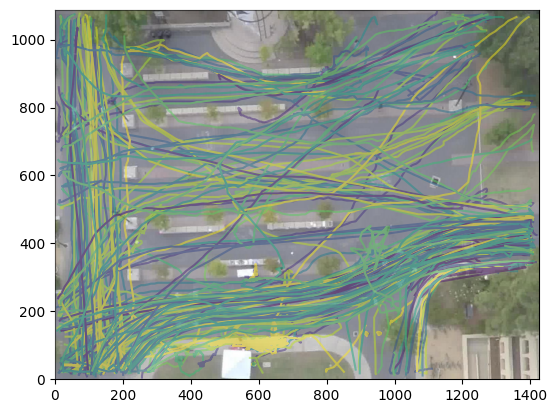

In [19]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from src.dataset import BaseDataset, SDDDataset
import matplotlib.pyplot as plt
from PIL import Image

def plot(data_path):
    data_path = Path(data_path)
    name = (
        data_path.parent.parent.name
        + "-"
        + data_path.parent.name.removeprefix("video")
    )

    ## 读取数据
    df_data = pd.read_csv(
        data_path,
        sep=" ",
        names=[
            "id", "xmin", "ymin", "xmax", "ymax",
            "frame", "lost", "occluded", "generated", "label",
        ],
        usecols=["id", "xmin", "ymin", "xmax", "ymax", "frame", "label"],
    )
    df_data["x"] = (df_data["xmin"] + df_data["xmax"]) / 2
    df_data["y"] = (df_data["ymin"] + df_data["ymax"]) / 2
    df_data = df_data.rename(columns={"frame": "f", "label": "type"})
    df_data['type'] = df_data['type'].replace({
        'Pedestrian': 'pedestrian',
        'Skater': 'vehicle',
        'Biker': 'vehicle',
        'Cart': 'vehicle',
        'Car': 'vehicle',
        'Bus': 'vehicle',
    })
    df_data = df_data[['f', 'id', 'x', 'y', 'type']]

    ## 仿射变换
    # H = cls.get_homography_mat(mat_name=data_path.parent.parent.name)
    # df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)

    ## 数据重采样
    df_data = SDDDataset.resample_dataframe(df_data, raw_fps=SDDDataset.raw_fps, target_fps=2.5)

    image = np.array(Image.open(data_path.parent / 'reference.jpg'))
    h, w  = image.shape[:2]
    plt.imshow(image, extent=[0, w, 0, h], alpha=1.0)
    for pid, group in df_data.groupby('id'):
        cmap = plt.get_cmap('viridis')
        plt.plot(group['x'], h-group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
    plt.imshow(image, extent=[0, w, 0, h], alpha=0.5, zorder=999999)

plot('./data/SDD/annotations/bookstore/video0/annotations.txt')

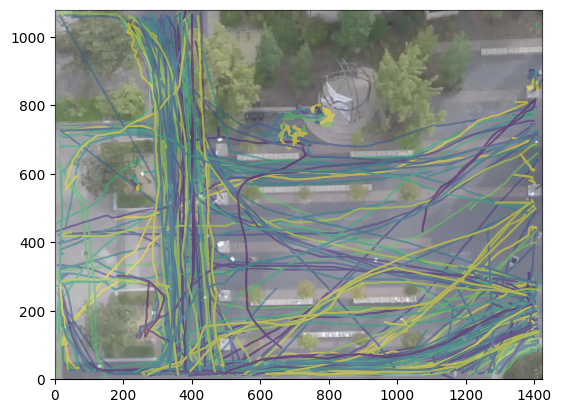

In [20]:
plot('./data/SDD/annotations/bookstore/video1/annotations.txt')

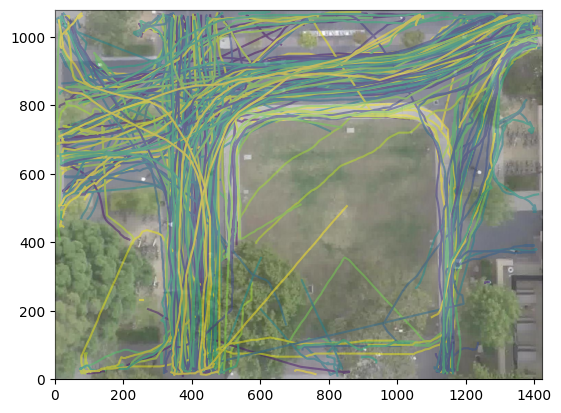

In [21]:
plot('./data/SDD/annotations/bookstore/video2/annotations.txt')


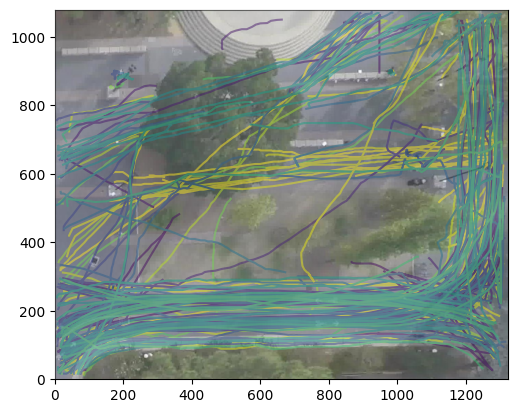

In [22]:
plot('./data/SDD/annotations/bookstore/video3/annotations.txt')


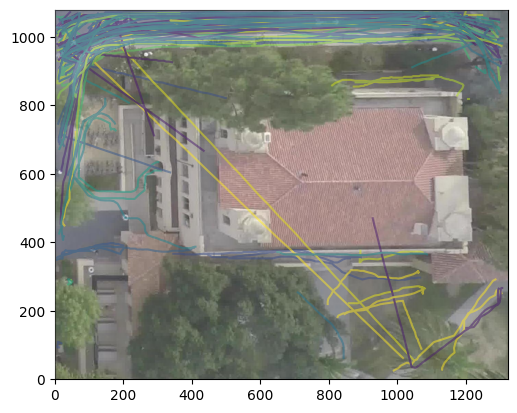

In [23]:
plot('./data/SDD/annotations/bookstore/video4/annotations.txt')

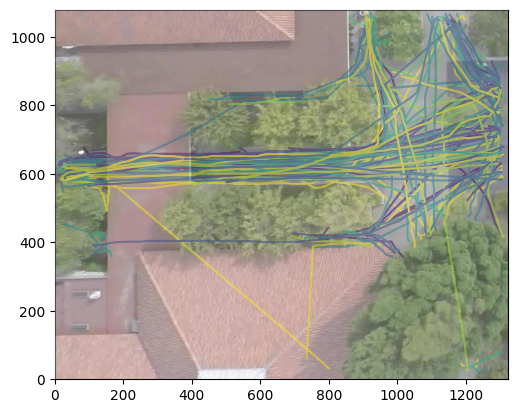

In [24]:
plot('./data/SDD/annotations/bookstore/video5/annotations.txt')

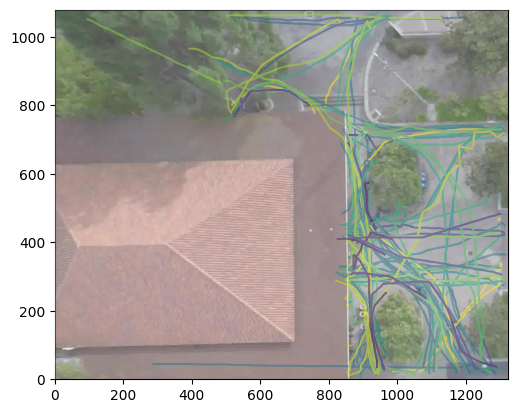

In [25]:
plot('./data/SDD/annotations/bookstore/video6/annotations.txt')

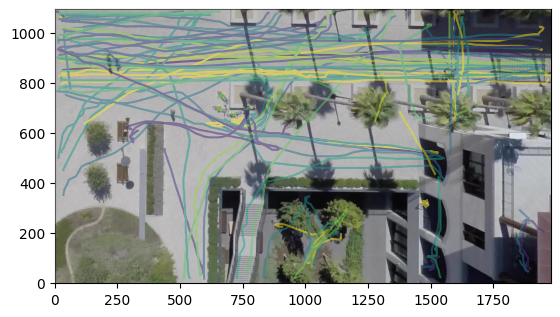

In [26]:
plot('./data/SDD/annotations/coupa/video0/annotations.txt')

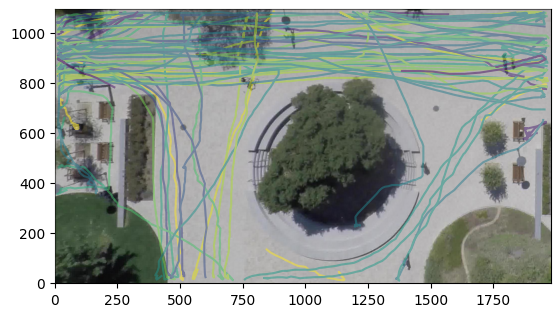

In [27]:
plot('./data/SDD/annotations/coupa/video1/annotations.txt')

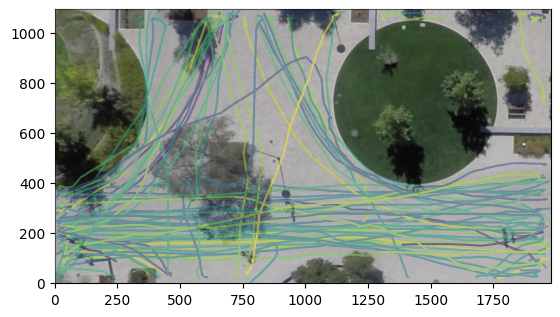

In [28]:
plot('./data/SDD/annotations/coupa/video2/annotations.txt')

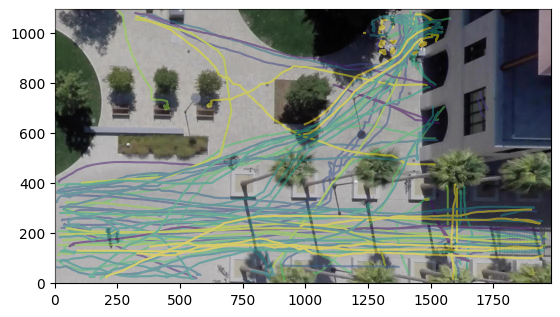

In [29]:
plot('./data/SDD/annotations/coupa/video3/annotations.txt')

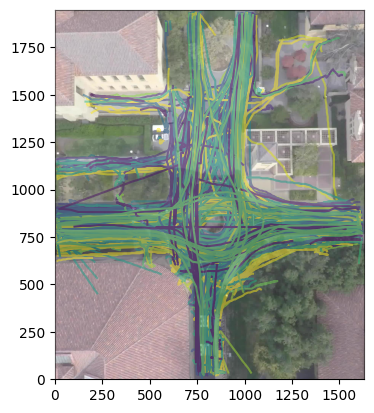

In [31]:
plot('./data/SDD/annotations/deathCircle/video0/annotations.txt')

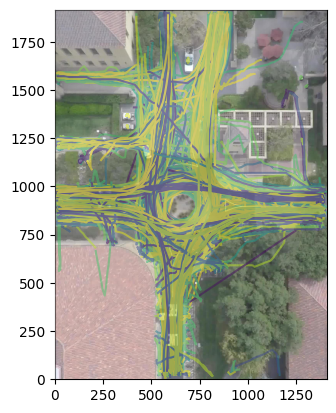

In [32]:
plot('./data/SDD/annotations/deathCircle/video1/annotations.txt')